In [3]:
from IPython.display import display, Markdown

In [4]:
with open("ds_szablon.md", "r", encoding="utf-8") as f:
    content = f.read()
display(Markdown(content))

# Projekt: od surowych danych do prostego modelu ML

## Cel projektu

W tym projekcie:
- poznasz dane poprzez EDA (Exploratory Data Analysis),
- przygotujesz dane (preprocessing: braki, kategorie, skalowanie),
- zbudujesz prosty model ML (regresja lub klasyfikacja),
- opiszesz swoje wnioski w Markdown.

Czas pracy: ok. 100 minut.

Na początek:
- opisz jednym akapitem, jaki problem chcesz rozwiązać (np. przewidywanie ceny, klasyfikacja klienta, itp.),
- napisz, jaka jest Twoja hipoteza lub intuicja dotycząca tych danych.

## 1. Importy i wczytanie danych

W tej sekcji:
- zaimportujemy potrzebne biblioteki,
- wczytamy dane do obiektu `DataFrame`,
- zrobimy pierwsze szybkie spojrzenie na dane.

Uzupełnij ścieżkę/URL do swojego pliku CSV.

```python
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix

import matplotlib.pyplot as plt

# TODO: Podaj nazwę pliku lub URL z danymi
# Przykład: df = pd.read_csv("dane.csv")
df = pd.read_csv("dane.csv")

df.head()
```

## 2. Pierwsze spojrzenie na dane

Sprawdzimy:
- kształt danych,
- typy kolumn,
- podstawowe statystyki,
- brakujące wartości.

Na końcu opisz w kilku zdaniach, co widzisz w danych.

```python
# Kształt danych (liczba wierszy i kolumn)
df.shape
```

```python
# Informacje o typach danych i brakach
df.info()
```

```python
# Statystyki opisowe
df.describe(include="all")
```

```python
# Liczba braków w każdej kolumnie
df.isna().sum()
```

### Komentarz: pierwsze wrażenia

Opisz:
- ile masz obserwacji i cech,
- które kolumny wyglądają na ważne,
- gdzie widać dużo braków,
- co może być dobrą zmienną docelową (targetem).

## 3. EDA: rozkłady, outliery, korelacje

W tej części:
- obejrzymy rozkłady zmiennych numerycznych (histogramy),
- sprawdzimy outliery (boxploty),
- policzymy macierz korelacji.

Na końcu opisz, jakie zależności i problemy zauważasz.

```python
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols
```

```python
for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Liczba obserwacji")
    plt.show()
```

```python
for col in numeric_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Boxplot: {col}")
    plt.show()
```

```python
corr = df.corr(numeric_only=True)
corr
```

## 4. Preprocessing danych

Tutaj:
- obsłużysz braki danych,
- zakodujesz zmienne kategoryczne,
- przygotujesz cechy i target,
- zastosujesz skalowanie cech.

Zapisz swoje decyzje i ich uzasadnienie.

```python
data = df.copy()

# Przykład: imputacja medianą dla kolumn numerycznych
for col in numeric_cols:
    if data[col].isna().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

# Przykład: wypełnianie braków w kolumnach kategorycznych
cat_cols = data.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    if data[col].isna().sum() > 0:
        data[col] = data[col].fillna("brak_danych")
```

```python
data_encoded = pd.get_dummies(data, drop_first=True)
data_encoded.head()
```

### Wybór zmiennej docelowej (targetu)

Wskaż, która kolumna będzie Twoim targetem (`y`) i uzasadnij krótko wybór.

```python
# TODO: podmień 'target' na nazwę wybranej kolumny docelowej
target_col = "target"

X = data_encoded.drop(target_col, axis=1)
y = data_encoded[target_col]

X.shape, y.shape
```

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

## 5. Model ML: regresja lub klasyfikacja

Wybierz odpowiedni typ modelu.

```python
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape
```

### 5.1. Model regresyjny (opcjonalnie)

```python
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred_reg = reg_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_reg)
mae = mean_absolute_error(y_test, y_pred_reg)

mse, mae
```

### 5.2. Model klasyfikacyjny (opcjonalnie)

```python
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred_clf = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred_clf)
cm = confusion_matrix(y_test, y_pred_clf)

acc, cm
```

## 6. Podsumowanie i wnioski

Napisz krótkie podsumowanie projektu, odpowiadając na pytania:
- czego dowiedziałeś/dowiedziałaś się o danych,
- jakie decyzje preprocessingowe podjąłeś/podjęłaś,
- jak poradził sobie model,
- co można by zrobić dalej.


In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix

import matplotlib.pyplot as plt

# TODO: Podaj nazwę pliku lub URL z danymi
# Przykład: df = pd.read_csv("dane.csv")
df = pd.read_csv("poe_stats.csv")

df.head()

,rank,dead,online,name,level,class,id,experience,account,challenges,twitch,ladder
0,1,False,False,Tzn_NecroIsFineNow,100,Necromancer,3dcddd59f5088893f734f39686350990dae168cc4f4b00...,4250334444,TheTzn,40,thetzn,Harbinger
1,1,False,False,RaizNeverFirstQT,100,Necromancer,8f3216db5ac9106c287a834731aafc83c387138f28fc45...,4250334444,RaizQT,22,raizqt,SSF Harbinger HC
2,1,False,False,GucciStreamerAdvantage,100,Necromancer,c6ec2dae3855c551e0597c06ef2da06fbb5512487ded7f...,4250334444,GucciPradas,35,guccipradas,Hardcore Harbinger
3,1,False,False,ChiroxPrime,100,Slayer,c861372da792be0b22c45bf437ccd58437c52e9455e0bf...,4250334444,Chiroxun,26,NaN,SSF Harbinger
4,2,False,False,Cool_NecroIsFineNow,100,Deadeye,24ae924ceed7989ef3d3d6772612832bb467a6094352c7...,4250334444,cooltail,22,NaN,Harbinger


Moim celem jest przewidzenie postępu gracza (logarytm doświadczenia). Hipoteza: Pozycja w rankingu i liczba ukończonych wyzwań będą miały największy wpływ na tę wartość, silniejszy niż wybór klasy postaci

In [6]:
df.shape

(59776, 12)

Blisko 60 000 rekordów, 12 kolumn

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59776 entries, 0 to 59775
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   rank        59776 non-null  int64 
 1   dead        59776 non-null  bool  
 2   online      59776 non-null  bool  
 3   name        59776 non-null  object
 4   level       59776 non-null  int64 
 5   class       59776 non-null  object
 6   id          59776 non-null  object
 7   experience  59776 non-null  int64 
 8   account     59776 non-null  object
 9   challenges  59776 non-null  int64 
 10  twitch      16300 non-null  object
 11  ladder      59776 non-null  object
dtypes: bool(2), int64(4), object(6)
memory usage: 4.7+ MB


Braki (NaN) widoczne jedynie w kolumnie "twitch" -> Zamiana na bool jako że nie interesują nas konkretni streamerzy

In [8]:
df.describe(include='all')

,rank,dead,online,name,level,class,id,experience,account,challenges,twitch,ladder
count,59776.000000,59776,59776,59776,59776.000000,59776,59776,5.977600e+04,59776,59776.000000,16300,59776
unique,NaN,2,2,58286,NaN,26,59776,NaN,37123,NaN,9613,4
top,NaN,False,False,_Flic_,NaN,Berserker,3dcddd59f5088893f734f39686350990dae168cc4f4b00...,NaN,chuz101,NaN,thespunkylobster,SSF Harbinger
freq,NaN,39195,58905,14,NaN,8711,1,NaN,30,NaN,18,14981
mean,7495.369379,NaN,NaN,NaN,85.422578,NaN,NaN,1.825786e+09,NaN,25.759569,NaN,NaN
std,4330.179898,NaN,NaN,NaN,11.288017,NaN,NaN,1.094748e+09,NaN,8.440888,NaN,NaN
min,1.000000,NaN,NaN,NaN,53.000000,NaN,NaN,7.790982e+07,NaN,4.000000,NaN,NaN
25%,3745.000000,NaN,NaN,NaN,78.000000,NaN,NaN,7.774697e+08,NaN,19.000000,NaN,NaN
50%,7492.000000,NaN,NaN,NaN,90.000000,NaN,NaN,1.934010e+09,NaN,25.000000,NaN,NaN
75%,11247.000000,NaN,NaN,NaN,95.000000,NaN,NaN,2.876117e+09,NaN,33.000000,NaN,NaN


Około 27% graczy streamuje rozgrywkę (twitch)

26 różnych klas, najpopularniejszą jest Berserker

Średni poziom postaci to 85 ale połowa graczy ma poziom 90 lub wyższy

Średnia liczba ukończonych wyzwań to 26. 

Najczęściej graną dywizją jest SSF Harbinger.

większość postaci (prawie 40000) nadal żyła w momencie zebrania danych

75% wszystkich postaci ma poziom 95 lub niższy (top 25% postaci ma większy poziom). Przejście od poziomu 95 do 100 zajmuje więcej czasu niż od 1 do 95

(na marginesie, poziom 95 to wartość którą "niedzielny gracz" jest w stanie osiągnąć w 10-12h)

In [9]:
df.isna().sum()

rank              0
dead              0
online            0
name              0
level             0
class             0
id                0
experience        0
account           0
challenges        0
twitch        43476
ladder            0
dtype: int64

Braki tylko w kolumnie twitch -> Zamiana na wartości true/false

In [10]:
df['dead'].value_counts()

dead
False    39195
True     20581
Name: count, dtype: int64

wip_df = df.copy()

Dobrze będzie zamienić wartości w kolumnie experience na skalę logarytmiczną

In [11]:
wip_df = df.copy()

In [12]:
wip_df["experience_log"] = np.log10(wip_df["experience"])

In [13]:
wip_df

,rank,dead,online,name,level,class,id,experience,account,challenges,twitch,ladder,experience_log
0,1,False,False,Tzn_NecroIsFineNow,100,Necromancer,3dcddd59f5088893f734f39686350990dae168cc4f4b00...,4250334444,TheTzn,40,thetzn,Harbinger,9.628423
1,1,False,False,RaizNeverFirstQT,100,Necromancer,8f3216db5ac9106c287a834731aafc83c387138f28fc45...,4250334444,RaizQT,22,raizqt,SSF Harbinger HC,9.628423
2,1,False,False,GucciStreamerAdvantage,100,Necromancer,c6ec2dae3855c551e0597c06ef2da06fbb5512487ded7f...,4250334444,GucciPradas,35,guccipradas,Hardcore Harbinger,9.628423
3,1,False,False,ChiroxPrime,100,Slayer,c861372da792be0b22c45bf437ccd58437c52e9455e0bf...,4250334444,Chiroxun,26,NaN,SSF Harbinger,9.628423
4,2,False,False,Cool_NecroIsFineNow,100,Deadeye,24ae924ceed7989ef3d3d6772612832bb467a6094352c7...,4250334444,cooltail,22,NaN,Harbinger,9.628423
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59771,14999,True,False,ПроклятьеРекласта,89,Necromancer,d33b4f6e08c10e365765f9a36a8f36d561fd1d86f10ee1...,1786695653,Romanchik002,18,romanchik002,Hardcore Harbinger,9.252051
59772,15000,False,False,IshibashiSummoner,94,Necromancer,5764cfa387e0a87a4bebc1a3c5017e92de8bbb06445c47...,2720770853,Ishibashisan,33,NaN,Harbinger,9.434692
59773,15000,False,False,BLively,73,Slayer,9ac75ab75a47cee8a9dfb0a31912df8909720a8b20f9f1...,495034029,ruby01,19,NaN,SSF Harbinger,8.694635
59774,15000,False,False,vawddvaw,89,Gladiator,cf02dfc0c90b2df9c7ac76bbedd91e93c2a8a2ca629c15...,1786638972,Lecarn,24,lecarn,Hardcore Harbinger,9.252037


Dodać kolumnę postaci które są streamowane na podstawie kolumny twitch

In [14]:
wip_df["is_streaming"] = wip_df["twitch"].notnull().astype(int)

In [15]:
wip_df

,rank,dead,online,name,level,class,id,experience,account,challenges,twitch,ladder,experience_log,is_streaming
0,1,False,False,Tzn_NecroIsFineNow,100,Necromancer,3dcddd59f5088893f734f39686350990dae168cc4f4b00...,4250334444,TheTzn,40,thetzn,Harbinger,9.628423,1
1,1,False,False,RaizNeverFirstQT,100,Necromancer,8f3216db5ac9106c287a834731aafc83c387138f28fc45...,4250334444,RaizQT,22,raizqt,SSF Harbinger HC,9.628423,1
2,1,False,False,GucciStreamerAdvantage,100,Necromancer,c6ec2dae3855c551e0597c06ef2da06fbb5512487ded7f...,4250334444,GucciPradas,35,guccipradas,Hardcore Harbinger,9.628423,1
3,1,False,False,ChiroxPrime,100,Slayer,c861372da792be0b22c45bf437ccd58437c52e9455e0bf...,4250334444,Chiroxun,26,NaN,SSF Harbinger,9.628423,0
4,2,False,False,Cool_NecroIsFineNow,100,Deadeye,24ae924ceed7989ef3d3d6772612832bb467a6094352c7...,4250334444,cooltail,22,NaN,Harbinger,9.628423,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59771,14999,True,False,ПроклятьеРекласта,89,Necromancer,d33b4f6e08c10e365765f9a36a8f36d561fd1d86f10ee1...,1786695653,Romanchik002,18,romanchik002,Hardcore Harbinger,9.252051,1
59772,15000,False,False,IshibashiSummoner,94,Necromancer,5764cfa387e0a87a4bebc1a3c5017e92de8bbb06445c47...,2720770853,Ishibashisan,33,NaN,Harbinger,9.434692,0
59773,15000,False,False,BLively,73,Slayer,9ac75ab75a47cee8a9dfb0a31912df8909720a8b20f9f1...,495034029,ruby01,19,NaN,SSF Harbinger,8.694635,0
59774,15000,False,False,vawddvaw,89,Gladiator,cf02dfc0c90b2df9c7ac76bbedd91e93c2a8a2ca629c15...,1786638972,Lecarn,24,lecarn,Hardcore Harbinger,9.252037,1


In [76]:
df_classes = pd.get_dummies(wip_df, columns=["class"], dtype=int, drop_first=True)

In [77]:
df_classes

,rank,dead,online,name,level,id,experience,account,challenges,twitch,...,class_Pathfinder,class_Raider,class_Ranger,class_Saboteur,class_Scion,class_Shadow,class_Slayer,class_Templar,class_Trickster,class_Witch
0,1,False,False,Tzn_NecroIsFineNow,100,3dcddd59f5088893f734f39686350990dae168cc4f4b00...,4250334444,TheTzn,40,thetzn,...,0,0,0,0,0,0,0,0,0,0
1,1,False,False,RaizNeverFirstQT,100,8f3216db5ac9106c287a834731aafc83c387138f28fc45...,4250334444,RaizQT,22,raizqt,...,0,0,0,0,0,0,0,0,0,0
2,1,False,False,GucciStreamerAdvantage,100,c6ec2dae3855c551e0597c06ef2da06fbb5512487ded7f...,4250334444,GucciPradas,35,guccipradas,...,0,0,0,0,0,0,0,0,0,0
3,1,False,False,ChiroxPrime,100,c861372da792be0b22c45bf437ccd58437c52e9455e0bf...,4250334444,Chiroxun,26,NaN,...,0,0,0,0,0,0,1,0,0,0
4,2,False,False,Cool_NecroIsFineNow,100,24ae924ceed7989ef3d3d6772612832bb467a6094352c7...,4250334444,cooltail,22,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59771,14999,True,False,ПроклятьеРекласта,89,d33b4f6e08c10e365765f9a36a8f36d561fd1d86f10ee1...,1786695653,Romanchik002,18,romanchik002,...,0,0,0,0,0,0,0,0,0,0
59772,15000,False,False,IshibashiSummoner,94,5764cfa387e0a87a4bebc1a3c5017e92de8bbb06445c47...,2720770853,Ishibashisan,33,NaN,...,0,0,0,0,0,0,0,0,0,0
59773,15000,False,False,BLively,73,9ac75ab75a47cee8a9dfb0a31912df8909720a8b20f9f1...,495034029,ruby01,19,NaN,...,0,0,0,0,0,0,1,0,0,0
59774,15000,False,False,vawddvaw,89,cf02dfc0c90b2df9c7ac76bbedd91e93c2a8a2ca629c15...,1786638972,Lecarn,24,lecarn,...,0,0,0,0,0,0,0,0,0,0


In [78]:
df_classes["exp_log"] = np.log10(df_classes["experience"])

In [79]:
df_classes

,rank,dead,online,name,level,id,experience,account,challenges,twitch,...,class_Raider,class_Ranger,class_Saboteur,class_Scion,class_Shadow,class_Slayer,class_Templar,class_Trickster,class_Witch,exp_log
0,1,False,False,Tzn_NecroIsFineNow,100,3dcddd59f5088893f734f39686350990dae168cc4f4b00...,4250334444,TheTzn,40,thetzn,...,0,0,0,0,0,0,0,0,0,9.628423
1,1,False,False,RaizNeverFirstQT,100,8f3216db5ac9106c287a834731aafc83c387138f28fc45...,4250334444,RaizQT,22,raizqt,...,0,0,0,0,0,0,0,0,0,9.628423
2,1,False,False,GucciStreamerAdvantage,100,c6ec2dae3855c551e0597c06ef2da06fbb5512487ded7f...,4250334444,GucciPradas,35,guccipradas,...,0,0,0,0,0,0,0,0,0,9.628423
3,1,False,False,ChiroxPrime,100,c861372da792be0b22c45bf437ccd58437c52e9455e0bf...,4250334444,Chiroxun,26,NaN,...,0,0,0,0,0,1,0,0,0,9.628423
4,2,False,False,Cool_NecroIsFineNow,100,24ae924ceed7989ef3d3d6772612832bb467a6094352c7...,4250334444,cooltail,22,NaN,...,0,0,0,0,0,0,0,0,0,9.628423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59771,14999,True,False,ПроклятьеРекласта,89,d33b4f6e08c10e365765f9a36a8f36d561fd1d86f10ee1...,1786695653,Romanchik002,18,romanchik002,...,0,0,0,0,0,0,0,0,0,9.252051
59772,15000,False,False,IshibashiSummoner,94,5764cfa387e0a87a4bebc1a3c5017e92de8bbb06445c47...,2720770853,Ishibashisan,33,NaN,...,0,0,0,0,0,0,0,0,0,9.434692
59773,15000,False,False,BLively,73,9ac75ab75a47cee8a9dfb0a31912df8909720a8b20f9f1...,495034029,ruby01,19,NaN,...,0,0,0,0,0,1,0,0,0,8.694635
59774,15000,False,False,vawddvaw,89,cf02dfc0c90b2df9c7ac76bbedd91e93c2a8a2ca629c15...,1786638972,Lecarn,24,lecarn,...,0,0,0,0,0,0,0,0,0,9.252037


In [80]:
df_classes.drop("experience", inplace=True, axis=1)

In [81]:
df_classes

,rank,dead,online,name,level,id,account,challenges,twitch,ladder,...,class_Raider,class_Ranger,class_Saboteur,class_Scion,class_Shadow,class_Slayer,class_Templar,class_Trickster,class_Witch,exp_log
0,1,False,False,Tzn_NecroIsFineNow,100,3dcddd59f5088893f734f39686350990dae168cc4f4b00...,TheTzn,40,thetzn,Harbinger,...,0,0,0,0,0,0,0,0,0,9.628423
1,1,False,False,RaizNeverFirstQT,100,8f3216db5ac9106c287a834731aafc83c387138f28fc45...,RaizQT,22,raizqt,SSF Harbinger HC,...,0,0,0,0,0,0,0,0,0,9.628423
2,1,False,False,GucciStreamerAdvantage,100,c6ec2dae3855c551e0597c06ef2da06fbb5512487ded7f...,GucciPradas,35,guccipradas,Hardcore Harbinger,...,0,0,0,0,0,0,0,0,0,9.628423
3,1,False,False,ChiroxPrime,100,c861372da792be0b22c45bf437ccd58437c52e9455e0bf...,Chiroxun,26,NaN,SSF Harbinger,...,0,0,0,0,0,1,0,0,0,9.628423
4,2,False,False,Cool_NecroIsFineNow,100,24ae924ceed7989ef3d3d6772612832bb467a6094352c7...,cooltail,22,NaN,Harbinger,...,0,0,0,0,0,0,0,0,0,9.628423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59771,14999,True,False,ПроклятьеРекласта,89,d33b4f6e08c10e365765f9a36a8f36d561fd1d86f10ee1...,Romanchik002,18,romanchik002,Hardcore Harbinger,...,0,0,0,0,0,0,0,0,0,9.252051
59772,15000,False,False,IshibashiSummoner,94,5764cfa387e0a87a4bebc1a3c5017e92de8bbb06445c47...,Ishibashisan,33,NaN,Harbinger,...,0,0,0,0,0,0,0,0,0,9.434692
59773,15000,False,False,BLively,73,9ac75ab75a47cee8a9dfb0a31912df8909720a8b20f9f1...,ruby01,19,NaN,SSF Harbinger,...,0,0,0,0,0,1,0,0,0,8.694635
59774,15000,False,False,vawddvaw,89,cf02dfc0c90b2df9c7ac76bbedd91e93c2a8a2ca629c15...,Lecarn,24,lecarn,Hardcore Harbinger,...,0,0,0,0,0,0,0,0,0,9.252037


In [82]:
df_classes.drop("id", inplace=True, axis=1)

In [83]:
df_classes

,rank,dead,online,name,level,account,challenges,twitch,ladder,experience_log,...,class_Raider,class_Ranger,class_Saboteur,class_Scion,class_Shadow,class_Slayer,class_Templar,class_Trickster,class_Witch,exp_log
0,1,False,False,Tzn_NecroIsFineNow,100,TheTzn,40,thetzn,Harbinger,9.628423,...,0,0,0,0,0,0,0,0,0,9.628423
1,1,False,False,RaizNeverFirstQT,100,RaizQT,22,raizqt,SSF Harbinger HC,9.628423,...,0,0,0,0,0,0,0,0,0,9.628423
2,1,False,False,GucciStreamerAdvantage,100,GucciPradas,35,guccipradas,Hardcore Harbinger,9.628423,...,0,0,0,0,0,0,0,0,0,9.628423
3,1,False,False,ChiroxPrime,100,Chiroxun,26,NaN,SSF Harbinger,9.628423,...,0,0,0,0,0,1,0,0,0,9.628423
4,2,False,False,Cool_NecroIsFineNow,100,cooltail,22,NaN,Harbinger,9.628423,...,0,0,0,0,0,0,0,0,0,9.628423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59771,14999,True,False,ПроклятьеРекласта,89,Romanchik002,18,romanchik002,Hardcore Harbinger,9.252051,...,0,0,0,0,0,0,0,0,0,9.252051
59772,15000,False,False,IshibashiSummoner,94,Ishibashisan,33,NaN,Harbinger,9.434692,...,0,0,0,0,0,0,0,0,0,9.434692
59773,15000,False,False,BLively,73,ruby01,19,NaN,SSF Harbinger,8.694635,...,0,0,0,0,0,1,0,0,0,8.694635
59774,15000,False,False,vawddvaw,89,Lecarn,24,lecarn,Hardcore Harbinger,9.252037,...,0,0,0,0,0,0,0,0,0,9.252037


In [84]:
df_classes.drop("experience_log", inplace=True, axis=1)

In [85]:
df_classes.drop("name", inplace=True, axis=1)

In [86]:
df_classes

,rank,dead,online,level,account,challenges,twitch,ladder,is_streaming,class_Assassin,...,class_Raider,class_Ranger,class_Saboteur,class_Scion,class_Shadow,class_Slayer,class_Templar,class_Trickster,class_Witch,exp_log
0,1,False,False,100,TheTzn,40,thetzn,Harbinger,1,0,...,0,0,0,0,0,0,0,0,0,9.628423
1,1,False,False,100,RaizQT,22,raizqt,SSF Harbinger HC,1,0,...,0,0,0,0,0,0,0,0,0,9.628423
2,1,False,False,100,GucciPradas,35,guccipradas,Hardcore Harbinger,1,0,...,0,0,0,0,0,0,0,0,0,9.628423
3,1,False,False,100,Chiroxun,26,NaN,SSF Harbinger,0,0,...,0,0,0,0,0,1,0,0,0,9.628423
4,2,False,False,100,cooltail,22,NaN,Harbinger,0,0,...,0,0,0,0,0,0,0,0,0,9.628423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59771,14999,True,False,89,Romanchik002,18,romanchik002,Hardcore Harbinger,1,0,...,0,0,0,0,0,0,0,0,0,9.252051
59772,15000,False,False,94,Ishibashisan,33,NaN,Harbinger,0,0,...,0,0,0,0,0,0,0,0,0,9.434692
59773,15000,False,False,73,ruby01,19,NaN,SSF Harbinger,0,0,...,0,0,0,0,0,1,0,0,0,8.694635
59774,15000,False,False,89,Lecarn,24,lecarn,Hardcore Harbinger,1,0,...,0,0,0,0,0,0,0,0,0,9.252037


In [87]:
df_classes['dead'] = df_classes['dead'].astype(int)

In [88]:
numeric_cols = df_classes.select_dtypes(include=["int64", "float64"]).columns

In [89]:
numeric_cols

Index(['rank', 'level', 'challenges', 'exp_log'], dtype='object')

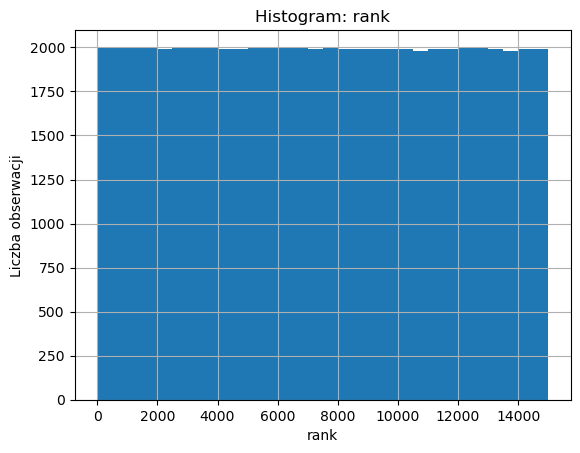

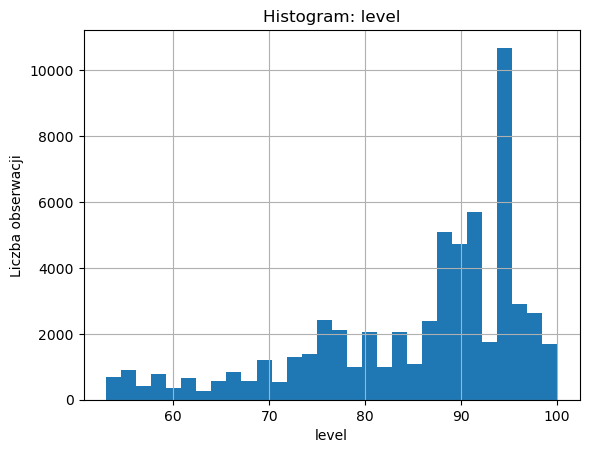

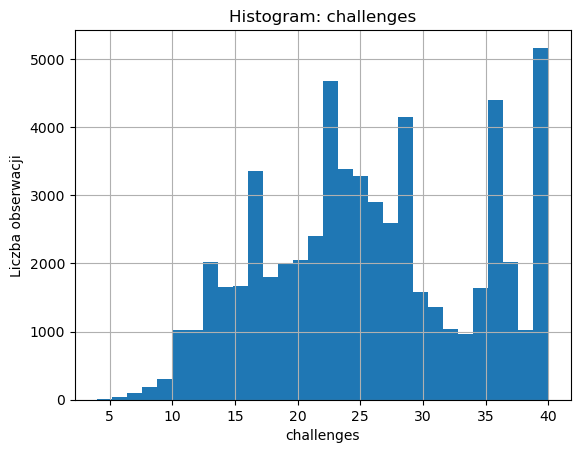

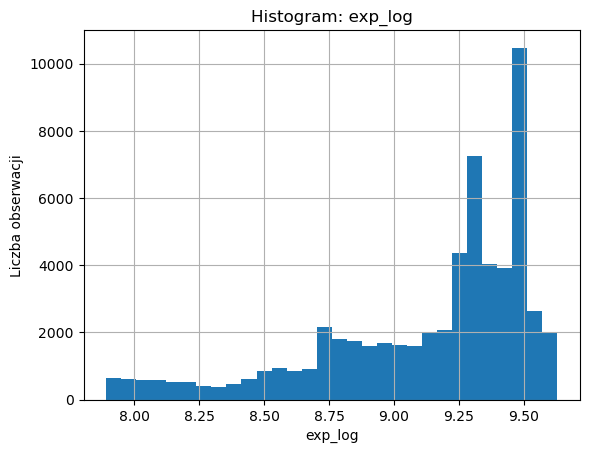

In [90]:
for col in numeric_cols:
    plt.figure()
    df_classes[col].hist(bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Liczba obserwacji")
    plt.show()

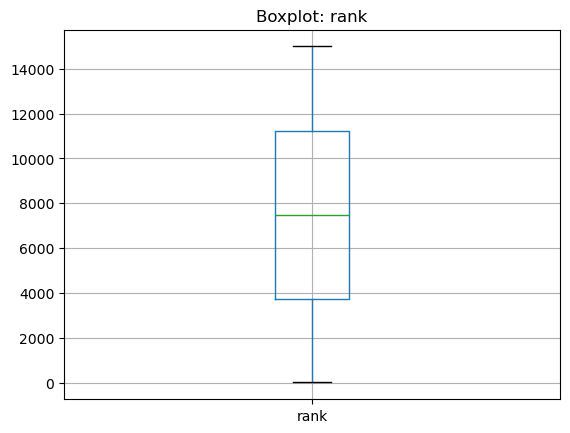

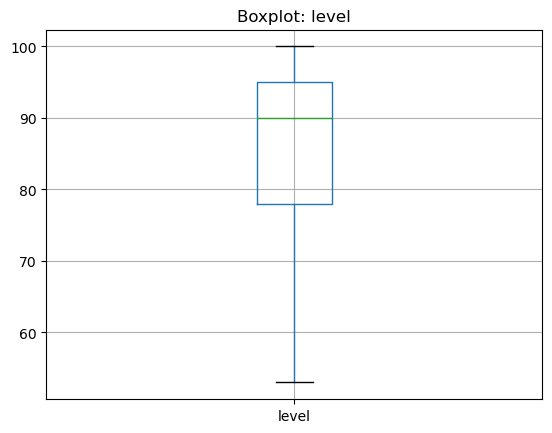

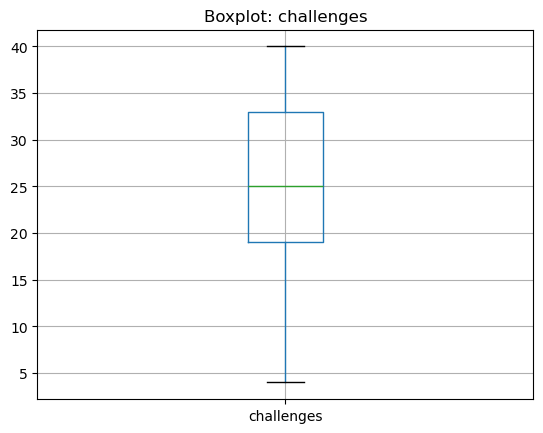

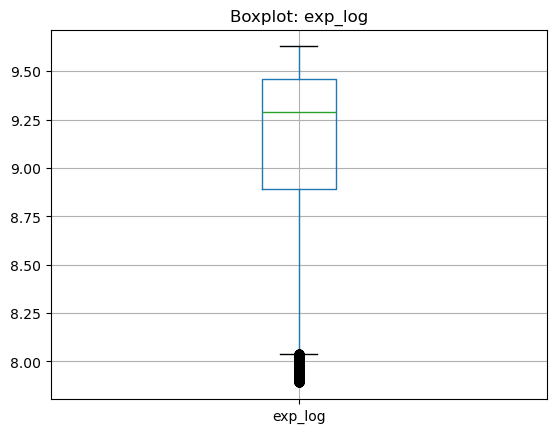

In [91]:
for col in numeric_cols:
    plt.figure()
    df_classes.boxplot(column=col)
    plt.title(f"Boxplot: {col}")
    plt.show()

Boxplot level: Pierwszy kwartyl w okolicach 78, trzeci kwartyl na poziomie około 95, mediana na poziomie 90 (zgodne z poprzednimi założeniami, poziomy 90-95 to granicą którą przeciętny gracz jest w stanie osiągnąć).

Boxplot challenges: Dane skoncentrowane między 19 a 33 z medianą w 25. Przecietna postać ukończy 25 wyzwań zanim zginie lub porzuci grę. 

Boxplot exp_log: Skala logarytmiczna punktów doświadczenia, oscyluje w wartościach 8.75 do 9.50. Gęsty rój outlierów na poziomie od ~7.75 do ~8.1.  Odpowiada to mniej więcej poziomowi 53-65. Duża liczba postaci ginie w tym poziomie lub jest porzucana.

In [92]:
df_classes.isnull().sum()

rank                      0
dead                      0
online                    0
level                     0
account                   0
challenges                0
twitch                43476
ladder                    0
is_streaming              0
class_Assassin            0
class_Berserker           0
class_Champion            0
class_Chieftain           0
class_Deadeye             0
class_Duelist             0
class_Elementalist        0
class_Gladiator           0
class_Guardian            0
class_Hierophant          0
class_Inquisitor          0
class_Juggernaut          0
class_Marauder            0
class_Necromancer         0
class_Occultist           0
class_Pathfinder          0
class_Raider              0
class_Ranger              0
class_Saboteur            0
class_Scion               0
class_Shadow              0
class_Slayer              0
class_Templar             0
class_Trickster           0
class_Witch               0
exp_log                   0
dtype: int64

Braki w kolumnie twitch potraktowano jako informację o tym że postać nie jest streamowana.

Kolumna "class" przemianowana na osobne kolumny binarne dla każdej wartości

In [100]:
df_final = pd.get_dummies(df_classes, columns=['ladder'], dtype=int, drop_first=True)
df_final

,rank,dead,online,level,account,challenges,twitch,is_streaming,class_Assassin,class_Berserker,...,class_Scion,class_Shadow,class_Slayer,class_Templar,class_Trickster,class_Witch,exp_log,ladder_Hardcore Harbinger,ladder_SSF Harbinger,ladder_SSF Harbinger HC
0,1,0,False,100,TheTzn,40,thetzn,1,0,0,...,0,0,0,0,0,0,9.628423,0,0,0
1,1,0,False,100,RaizQT,22,raizqt,1,0,0,...,0,0,0,0,0,0,9.628423,0,0,1
2,1,0,False,100,GucciPradas,35,guccipradas,1,0,0,...,0,0,0,0,0,0,9.628423,1,0,0
3,1,0,False,100,Chiroxun,26,NaN,0,0,0,...,0,0,1,0,0,0,9.628423,0,1,0
4,2,0,False,100,cooltail,22,NaN,0,0,0,...,0,0,0,0,0,0,9.628423,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59771,14999,1,False,89,Romanchik002,18,romanchik002,1,0,0,...,0,0,0,0,0,0,9.252051,1,0,0
59772,15000,0,False,94,Ishibashisan,33,NaN,0,0,0,...,0,0,0,0,0,0,9.434692,0,0,0
59773,15000,0,False,73,ruby01,19,NaN,0,0,0,...,0,0,1,0,0,0,8.694635,0,1,0
59774,15000,0,False,89,Lecarn,24,lecarn,1,0,0,...,0,0,0,0,0,0,9.252037,1,0,0


In [101]:
corr=df_classes.corr(numeric_only=True)
corr

,rank,dead,online,level,challenges,is_streaming,class_Assassin,class_Berserker,class_Champion,class_Chieftain,...,class_Raider,class_Ranger,class_Saboteur,class_Scion,class_Shadow,class_Slayer,class_Templar,class_Trickster,class_Witch,exp_log
rank,1.000000,0.042754,-0.040522,-0.452510,-0.257123,-0.055688,0.033443,0.010148,0.002886,0.001433,...,0.012211,0.025151,0.007491,0.030298,0.030974,-0.009430,0.040189,-0.006258,0.047866,-0.454118
dead,0.042754,1.000000,-0.085765,-0.333407,-0.210822,0.034619,-0.002917,-0.037742,0.022529,0.034119,...,-0.069912,0.006804,0.010199,0.016835,0.015442,-0.007744,0.028167,0.036616,0.029249,-0.332686
online,-0.040522,-0.085765,1.000000,0.082778,0.062610,-0.010505,-0.001177,-0.003929,-0.006644,-0.006806,...,0.025852,-0.003447,-0.012210,-0.003588,-0.003375,-0.000930,-0.004193,-0.013661,-0.005431,0.081298
level,-0.452510,-0.333407,0.082778,1.000000,0.597135,0.098815,-0.051031,0.057680,-0.005153,-0.023841,...,0.045491,-0.046319,-0.033049,-0.057156,-0.055446,0.050096,-0.076547,-0.057166,-0.089583,0.999139
challenges,-0.257123,-0.210822,0.062610,0.597135,1.000000,0.186115,-0.034202,0.035334,-0.028411,-0.031902,...,0.055209,-0.027250,-0.008951,-0.037747,-0.035875,0.047273,-0.051553,-0.051651,-0.058532,0.587189
is_streaming,-0.055688,0.034619,-0.010505,0.098815,0.186115,1.000000,-0.012461,-0.003871,-0.010267,-0.017391,...,0.010399,-0.009401,0.008221,0.001045,-0.011574,-0.009587,-0.009118,0.005308,-0.015548,0.097313
class_Assassin,0.033443,-0.002917,-0.001177,-0.051031,-0.034202,-0.012461,1.000000,-0.044272,-0.015446,-0.020604,...,-0.032912,-0.003039,-0.015862,-0.003163,-0.002975,-0.034070,-0.003696,-0.024889,-0.004787,-0.050757
class_Berserker,0.010148,-0.037742,-0.003929,0.057680,0.035334,-0.003871,-0.044272,1.000000,-0.059517,-0.079392,...,-0.126817,-0.011709,-0.061121,-0.012187,-0.011462,-0.131279,-0.014243,-0.095903,-0.018447,0.057219
class_Champion,0.002886,0.022529,-0.006644,-0.005153,-0.028411,-0.010267,-0.015446,-0.059517,1.000000,-0.027699,...,-0.044246,-0.004085,-0.021325,-0.004252,-0.003999,-0.045803,-0.004969,-0.033460,-0.006436,-0.004007
class_Chieftain,0.001433,0.034119,-0.006806,-0.023841,-0.031902,-0.017391,-0.020604,-0.079392,-0.027699,1.000000,...,-0.059021,-0.005449,-0.028446,-0.005672,-0.005334,-0.061098,-0.006629,-0.044634,-0.008585,-0.022629


In [102]:
import seaborn as sns

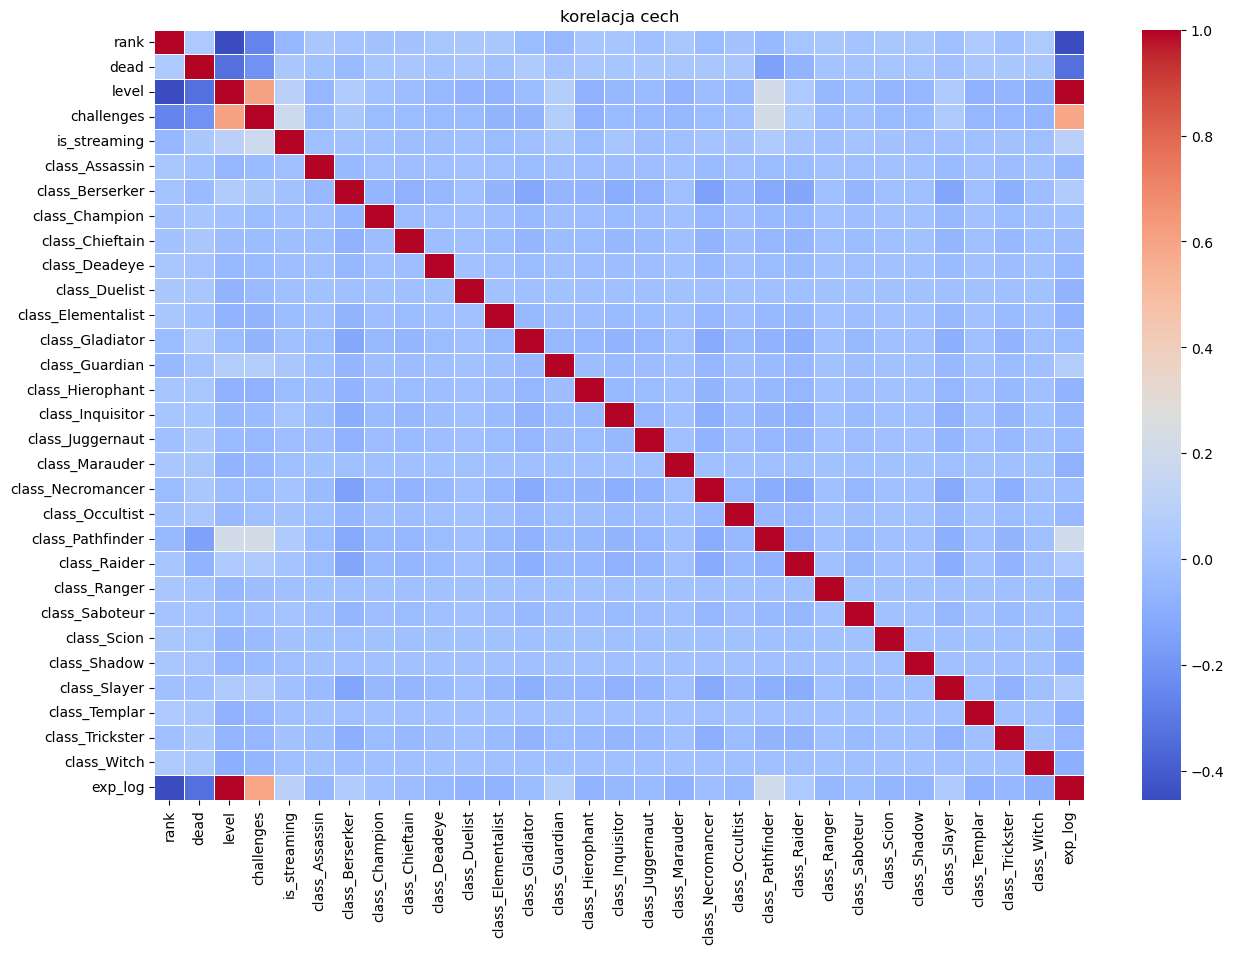

In [103]:
corr_matrix = df_classes.select_dtypes(include=['int64', 'float64', 'int32', 'uint8']).corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("korelacja cech")
plt.show()

Korelacje:
level i exp_log = Idealna korelacja (logiczne, im większe exp_log tym większy poziom) - usunięcie level z cech X

exp_log i rank = Silna korelacja odwrotna. Im wyższa pozycja w rankingu, tym większy logarytm punktów doświadczenia

Challenges i rank = Umiarkowana korelacja odwrotna. Ma to związek z tym że rank jest liczony na opak, im mniejsza wartość tym jest ona wyżej. Mówi o tym że mamy sytuację w której topowi gracze ignorują wyzwania i/lub gracze na dole rankingu są komplecjonistami. 
Challenges i exp_log = dosyć silna korelacja. Im większa skala doświadczenia, tym więcej wyzwań zaliczonych. Gracz który wbił wystarczająco duży poziom, naturalnie wykonał wyzwania, ale maluje się tutaj dualizm stylów grania:
Grinder (Zdobywa punkty exp żeby odblokować końcową zawartość gry (end-game(tam jest całe "mięso") dopisek)) vs Completionist (Skupia się na zaliczaniu wyzwań, za które są unikalne nagrody)

is_streaming i challenges = Nikła korelacja, streamerzy nie mają znacznie więcej zaliczonych wyzwań, zwykli gracze kompletują osiągnięcia

In [104]:
X = df_final.drop(['exp_log', 'level', 'account', 'twitch'], axis=1)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59776 entries, 0 to 59775
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   rank                       59776 non-null  int64
 1   dead                       59776 non-null  int32
 2   online                     59776 non-null  bool 
 3   challenges                 59776 non-null  int64
 4   is_streaming               59776 non-null  int32
 5   class_Assassin             59776 non-null  int32
 6   class_Berserker            59776 non-null  int32
 7   class_Champion             59776 non-null  int32
 8   class_Chieftain            59776 non-null  int32
 9   class_Deadeye              59776 non-null  int32
 10  class_Duelist              59776 non-null  int32
 11  class_Elementalist         59776 non-null  int32
 12  class_Gladiator            59776 non-null  int32
 13  class_Guardian             59776 non-null  int32
 14  class_Hierophant      

In [105]:
target_col = "exp_log"
to_drop = ['exp_log', 'level', 'account', 'twitch', 'id', 'experience', 'ladder', 'class']
X = df_final.drop(columns=to_drop, errors='ignore')
X = X.astype(float)
y = df_final[target_col]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59776 entries, 0 to 59775
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   rank                       59776 non-null  float64
 1   dead                       59776 non-null  float64
 2   online                     59776 non-null  float64
 3   challenges                 59776 non-null  float64
 4   is_streaming               59776 non-null  float64
 5   class_Assassin             59776 non-null  float64
 6   class_Berserker            59776 non-null  float64
 7   class_Champion             59776 non-null  float64
 8   class_Chieftain            59776 non-null  float64
 9   class_Deadeye              59776 non-null  float64
 10  class_Duelist              59776 non-null  float64
 11  class_Elementalist         59776 non-null  float64
 12  class_Gladiator            59776 non-null  float64
 13  class_Guardian             59776 non-null  flo

In [106]:
X = X.drop(columns=['experience_log'], errors='ignore')

In [107]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59776 entries, 0 to 59775
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   rank                       59776 non-null  float64
 1   dead                       59776 non-null  float64
 2   online                     59776 non-null  float64
 3   challenges                 59776 non-null  float64
 4   is_streaming               59776 non-null  float64
 5   class_Assassin             59776 non-null  float64
 6   class_Berserker            59776 non-null  float64
 7   class_Champion             59776 non-null  float64
 8   class_Chieftain            59776 non-null  float64
 9   class_Deadeye              59776 non-null  float64
 10  class_Duelist              59776 non-null  float64
 11  class_Elementalist         59776 non-null  float64
 12  class_Gladiator            59776 non-null  float64
 13  class_Guardian             59776 non-null  flo

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [109]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [110]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [111]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test_scaler)
print(f"Błąd MAE: {mean_absolute_error(y_test, y_pred)}" )
print(f"Wynik R2: {r2_score(y_test, y_pred)}")

Błąd MAE: 0.10796626321815343
Wynik R2: 0.8743838392358076


In [112]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Średni błąd (MAE): {mae:.4f}")
print(f"Błąd kwadratowy (MSE): {mse:.4f}")
print(f"Jak dobrze dopasowany jest model (R2): {r2:.4f}")

Średni błąd (MAE): 0.1080
Błąd kwadratowy (MSE): 0.0215
Jak dobrze dopasowany jest model (R2): 0.8744


In [117]:
importance = pd.DataFrame({
    'Cecha': X.columns,
    'Waga': model.coef_
})
importance['Abs_Waga'] = importance['Waga'].abs()
importance = importance.sort_values(by='Abs_Waga', ascending=False).drop('Abs_Waga', axis=1)
print("cechy dla przewidywania poziomu (exp_log):")
print(importance)

cechy dla przewidywania poziomu (exp_log):
                        Cecha      Waga
32    ladder_SSF Harbinger HC -0.359721
31       ladder_SSF Harbinger -0.185862
0                        rank -0.179843
30  ladder_Hardcore Harbinger -0.053759
3                  challenges  0.016495
1                        dead -0.009060
29                class_Witch -0.008774
27              class_Templar -0.008232
10              class_Duelist -0.007697
17             class_Marauder -0.006622
25               class_Shadow -0.005976
24                class_Scion -0.005712
12            class_Gladiator  0.005681
6             class_Berserker  0.005509
26               class_Slayer  0.005404
22               class_Ranger -0.005203
7              class_Champion  0.004292
13             class_Guardian -0.004056
8             class_Chieftain  0.003440
20           class_Pathfinder -0.003430
28            class_Trickster  0.003243
16           class_Juggernaut  0.002873
11         class_Elementalist -0.0026

Na podstawie danych rank, challenges, dead, is_streaming i kolumn *_class model regresji liniowej uzyskał wsp determinacji R2 na poziomie 0.87. Oznacza to że przygotowane cechy pozwalają wyjaśnić aż 87% różnic w zdobywanym przez postacie doświadczeniu ( w skali logarytmicznej).

Średni błąd MAE na poziomie ~0.11 w skali logarytmicznej oznacza że model myli się o około 28% w szacowaniu surowej liczby punktów doświadczenia. (Na marginesie, w realiach Path of Exile na poziomach 90+ taka różnica to błąd rzędu 1 do 3 poziomów, niezbyt dużo)

Dane pokazują niemal liniową zależnośc między poziomem postaci a logarytmem doświadczenia.

Liczba osiągniętych wyzwań (challenges) oraz pozycja w rankingu (rank) okazały się świetnymi predykatorami postępu postaci, znacznie silniejszymi niż wybór konkretnej klasy czy streaming.

Na podstawie cech do przewidywania można wywnioskować:

Cechy ladder mają największy negatywny wpływ, postacie w ladderach Solo-self-found (brak wymieniania przedmiotów z innymi postaciami) i HC (śmierć postaci jest równoważna z jej usunięciem z ladder) zdobywają mniej doświadczenia niż postacie w mniej restrykcyjnych trybach. Jest to logiczne. Granie w trybach SSFHC jest trudniejsze, wolniejsze i postacie giną częściej zanim uda im się zdobyć wysoki poziom.

Cecha rank ma ujemną wagę, co ma sens w kontekście danych, im mniejsza wartość w kolumnie, tym wyżej postać się znajduje w rankingu.

Cechy class_* mają nikły na ilość zdobytego exp 

Cecha challenges nie dominuje w predykcji, sugeruje to że niektóre postacie ignorują wyzwania na rzecz zdobywania poziomów (power leveling) a inne robią wyzwania na niskich poziomach

Cecha streaming nie ma wpływu na predykcję. Streamerzy i zwykli gracze nie różnią się zbytnio umiejetnościami. Bycie streamerem nie koreluje z wyższym poziomem postaci.

Decyzje:

Transformacja Logarytmiczna: Zastosowałem logarytm dziesiętny dla kolumny experience, stabilizując wariancję i umożliwiając działanie modelom liniowym

One-Hot Encoding: Zmienne class i ladder zamieniono na dane binarne (0/1), co pozwoliło modelowi uwzględnić te archetypy w predykcji

Sprzątanie wycieków: usunięcie kolumn level i experience zapobiegło sytuacji w której model "ściąga" przed dokonaniem predykcji

Skalowanie: użyłem StandardScaler aby wyrównać znaczenie cech różnych zakresach (ranking w tysiącach vs wyzwania do 40)

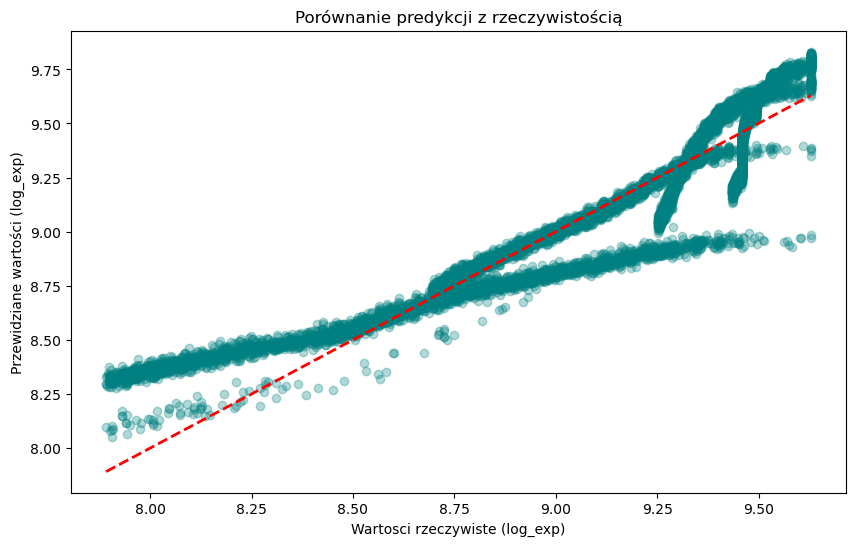

In [119]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Wartosci rzeczywiste (log_exp)')
plt.ylabel('Przewidziane wartości (log_exp)')
plt.title('Porównanie predykcji z rzeczywistością')
plt.show()